# Pelatihan Model Naïve Bayes — Deteksi Pesan Berbahaya

**Skripsi:** Perancangan Sistem Pengamanan Data dengan Klasifikasi Naïve Bayes dan Hybrid Cryptography AES–RSA  
**Dataset:** Dataset Gabungan (dataset_fixed + dataset_pesan + dataset_sms_spam + Dataset-Research)  
**Split:** Train 70% | Validasi 15% | Test 15%  
**Balancing:** SMOTE (Oversampling) pada data latih

In [5]:
!playwright install chromium

|                                                                                |   0% of 181.9 MiB
|■■■■■■■■                                                                        |  10% of 181.9 MiB
|■■■■■■■■■■■■■■■■                                                                |  20% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■                                                        |  30% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                                |  40% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                        |  50% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                |  60% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                        |  70% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                |  80% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■        |  90% of 

## 1. Import Library

In [26]:
import pandas as pd
import numpy as np
import joblib
import re
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print(" Semua library berhasil diimport (termasuk imbalanced-learn)")

 Semua library berhasil diimport (termasuk imbalanced-learn)


## 2. Load dan Gabungkan Dataset

Dua sumber data:
- **Dataset Dummy** (Peneliti): 1.235 data, Bahasa Indonesia
- **SMS Spam Collection** (Kaggle): 5.572 data, Bahasa Inggris → label `spam`→`Berisiko`, `ham`→`Tidak Berisiko`

In [27]:
print("=" * 60)
print("  LANGKAH 1 — LOAD DAN GABUNGKAN DATASET")
print("=" * 60)

# ── 1. dataset_fixed.csv ─────────────────────────────────────────
df_fixed = pd.read_csv('Dataset/dataset_fixed.csv')
df_fixed = df_fixed[['pesan','kategori','label']].copy()
print(f"\n[1] dataset_fixed.csv")
print(f"  Jumlah : {len(df_fixed)} baris")
print(f"  Label  : {df_fixed['label'].value_counts().to_dict()}")

# ── 2. dataset_pesan.csv ─────────────────────────────────────────
df_pesan = pd.read_csv('Dataset/dataset_pesan.csv')
df_pesan = df_pesan[['pesan','kategori','label']].copy()
print(f"\n[2] dataset_pesan.csv")
print(f"  Jumlah : {len(df_pesan)} baris")
print(f"  Label  : {df_pesan['label'].value_counts().to_dict()}")

# ── 3. dataset_sms_spam_v1.csv ───────────────────────────────────
# Label: 0=Normal/Ham, 1=Penipuan, 2=Promo/Spam
df_sms_raw = pd.read_csv('Dataset/dataset_sms_spam_v1.csv')
KATEGORI_SMS = {
    0: ('Percakapan Biasa',  'Tidak Berisiko'),
    1: ('Penipuan',          'Berisiko'),
    2: ('Penipuan',          'Berisiko'),
}
df_sms = pd.DataFrame({
    'pesan'    : df_sms_raw['Teks'],
    'kategori' : df_sms_raw['label'].map(lambda x: KATEGORI_SMS[x][0]),
    'label'    : df_sms_raw['label'].map(lambda x: KATEGORI_SMS[x][1]),
})
print(f"\n[3] dataset_sms_spam_v1.csv")
print(f"  Jumlah : {len(df_sms)} baris")
print(f"  Label asli → mapping : 0→Percakapan Biasa, 1&2→Penipuan")
print(f"  Label  : {df_sms['label'].value_counts().to_dict()}")

# ── 4. Dataset-Research.csv (TikTok Cyberbullying) ───────────────
# sentiment: -1=negatif/bullying, 1=positif/normal
df_res_raw = pd.read_csv('Dataset/Dataset-Research.csv')
df_res_raw['sentiment'] = df_res_raw['sentiment'].astype(str).str.strip()
KATEGORI_RES = {
    '-1': ('Kata Kasar & Ancaman', 'Berisiko'),
    '1' : ('Percakapan Biasa',     'Tidak Berisiko'),
}
df_res = pd.DataFrame({
    'pesan'    : df_res_raw['comment'],
    'kategori' : df_res_raw['sentiment'].map(
                    lambda x: KATEGORI_RES.get(str(x), ('Percakapan Biasa','Tidak Berisiko'))[0]),
    'label'    : df_res_raw['sentiment'].map(
                    lambda x: KATEGORI_RES.get(str(x), ('Percakapan Biasa','Tidak Berisiko'))[1]),
})
print(f"\n[4] Dataset-Research.csv")
print(f"  Jumlah : {len(df_res)} baris")
print(f"  Label asli → mapping : -1→Kata Kasar & Ancaman, 1→Percakapan Biasa")
print(f"  Label  : {df_res['label'].value_counts().to_dict()}")

# ── Gabungkan semua ───────────────────────────────────────────────
df_all = pd.concat([df_fixed, df_pesan, df_sms, df_res], ignore_index=True)
df_all['pesan'] = df_all['pesan'].astype(str).str.strip()
df_all = df_all.dropna(subset=['pesan'])
df_all = df_all[df_all['pesan'].str.len() >= 3]
df_all = df_all.drop_duplicates(subset=['pesan'])
df_all = df_all.reset_index(drop=True)

print(f"\n{'='*60}")
print(f"[Dataset Gabungan Final]")
print(f"  Total data : {len(df_all)} baris")
print(f"  Label      :")
for lbl, cnt in df_all['label'].value_counts().items():
    print(f"    - {lbl}: {cnt}")
print(f"  Kategori   :")
for kat, cnt in df_all['kategori'].value_counts().items():
    print(f"    - {kat}: {cnt}")
print(f"\nContoh data gabungan:")
print(df_all[['pesan','kategori','label']].sample(6, random_state=42).to_string(index=False))



  LANGKAH 1 — LOAD DAN GABUNGKAN DATASET

[1] dataset_fixed.csv
  Jumlah : 2181 baris
  Label  : {'Berisiko': 1680, 'Tidak Berisiko': 501}

[2] dataset_pesan.csv
  Jumlah : 33270 baris
  Label  : {'Tidak Berisiko': 31989, 'Berisiko': 1281}

[3] dataset_sms_spam_v1.csv
  Jumlah : 1143 baris
  Label asli → mapping : 0→Percakapan Biasa, 1&2→Penipuan
  Label  : {'Berisiko': 574, 'Tidak Berisiko': 569}

[4] Dataset-Research.csv
  Jumlah : 1508 baris
  Label asli → mapping : -1→Kata Kasar & Ancaman, 1→Percakapan Biasa
  Label  : {'Tidak Berisiko': 832, 'Berisiko': 676}

[Dataset Gabungan Final]
  Total data : 38070 baris
  Label      :
    - Tidak Berisiko: 33878
    - Berisiko: 4192
  Kategori   :
    - Percakapan Biasa: 26468
    - Informasi Umum: 3193
    - Kata Kasar & Ancaman: 2741
    - Transaksi Aman: 2380
    - Jadwal & Kegiatan: 1837
    - Penipuan: 667
    - Konten Ilegal: 242
    - Phishing: 162
    - Social Engineering: 157
    - Malware: 74
    - Pencurian Akun: 66
    - Phishin

## 3. Inisialisasi Tools NLP

In [28]:
print("=" * 60)
print("  INISIALISASI NLP")
print("=" * 60)

stemmer  = StemmerFactory().create_stemmer()
sw_base  = StopWordRemoverFactory().get_stop_words()
sw_extra = [
    'anda','kamu','saya','kami','kita','nya','ini','itu',
    'dengan','untuk','ada','akan','sudah','telah',
    'ya','yg','jg','gak','ga','deh','dong','nih','lah','sih',
    'ku','mu','klo','tapi','jadi','bisa','agar','juga',
]

# Kata kasar — TIDAK masuk stopwords agar jadi fitur model
KATA_KASAR = {
    'kontol','memek','pepek','titit','toket','ngentot','entot','ngewe',
    'colmek','coli','masturbasi','bokep','porno','telanjang','bugil',
    'binal','mesum','cabul','bejat',
    'anjing','bangsat','bajingan','brengsek','keparat','sialan',
    'babi','goblok','tolol','dungu','geblek','kampret',
    'asu','jancok','jancuk','cuk','kon','taik','tai','setan',
    'iblis','laknat','terkutuk','jahanam','lonte','sundal',
    'pelacur','jalang','murahan','perek',
    'kubunuh','mampusin','bacok','hajar','tonjok','siksa',
    'aniaya','habisi','musnahkan','gebuk','cekik',
    'kafir','rasis',
}


# Tambahan kata berisiko untuk deteksi rule-based tahap prediksi
KATA_KASAR.update({
    # Konten dewasa tambahan
    'peler','puting','nenen','susu','vagina','penis',
    'fwb','ons','cs','crot','smean','ebes','ani-ani','michat',
    'tetek','payudara',
    'lendir','esek-esek','bispak','jablay','pecun','desahan',
    'sange','horny','birahi','nudes','nude',
    'ngaceng','tegang','basah','montok',
    'ml','ngewe','ngentot','colmek','coli',
    'bo','vcs','vc',
    'pap','tt',
    # Kata kasar sebelumnya

    'pukimak','bacot','bego','goblog','bedebah','monyet',
    'anjir','anjirr','anjg','njing','njir','njirr',
    'tolol','goblok','goblog'
})

STOPWORDS = set(sw_base + sw_extra) - KATA_KASAR

POLA_URL = (
    r'(https?://|ftp://|bit\.ly|s\.id|rb\.gy|t\.ly|cutt\.ly'
    r'|tinyurl\.com|shorturl\.at|bit\.do|ow\.ly|is\.gd|tiny\.cc'
    r'|[\w-]+\.xyz|[\w-]+\.site)\S*'
)

print(f"  Stemmer      : Nazief-Adriani (Sastrawi) ")
print(f"  Stopwords    : {len(STOPWORDS)} kata (Sastrawi + custom)")
print(f"  Kata kasar   : {len(KATA_KASAR)} kata (blacklist, skip stopword & stemming)")
print(f"  Pola URL     : regex URL mencurigakan ")

  INISIALISASI NLP
  Stemmer      : Nazief-Adriani (Sastrawi) 
  Stopwords    : 138 kata (Sastrawi + custom)
  Kata kasar   : 111 kata (blacklist, skip stopword & stemming)
  Pola URL     : regex URL mencurigakan 


## 4. Preprocessing — Langkah 1: Case Folding

Mengubah seluruh teks menjadi huruf kecil (lowercase) untuk menyeragamkan bentuk kata.

In [29]:
print("=" * 60)
print("  LANGKAH 2 — CASE FOLDING")
print("=" * 60)
print("  Mengubah semua teks menjadi huruf kecil (lowercase)")

df_all['step_casefolding'] = df_all['pesan'].str.lower().str.strip()

# Tampilkan contoh (Tabel 3.10)
print("\n  Contoh (Tabel 3.10):")
print(f"  {'No':<4} {'Teks Asli':<55} {'Setelah Case Folding'}")
print("  " + "-"*110)
contoh_idx = df_all.sample(5, random_state=1).index
for no, i in enumerate(contoh_idx, 1):
    asli   = str(df_all['pesan'][i])[:52]
    bersih = str(df_all['step_casefolding'][i])[:52]
    print(f"  {no:<4} {asli:<55} {bersih}")

  LANGKAH 2 — CASE FOLDING
  Mengubah semua teks menjadi huruf kecil (lowercase)

  Contoh (Tabel 3.10):
  No   Teks Asli                                               Setelah Case Folding
  --------------------------------------------------------------------------------------------------------------
  1    kompensasinya bos, jangan masyarakat telat bayar yg     kompensasinya bos, jangan masyarakat telat bayar yg 
  2    bro minta dong                                          bro minta dong
  3    Donasi Rp1.000 Anda berhasil disalurkan. Terima kasi    donasi rp1.000 anda berhasil disalurkan. terima kasi
  4    kami di palembng kabupaten Muba masih mati lampu, dr    kami di palembng kabupaten muba masih mati lampu, dr
  5    Ya Tuhan, Tuhanku, kamu melindungi kedua orang tuaku    ya tuhan, tuhanku, kamu melindungi kedua orang tuaku


## 5. Preprocessing — Langkah 2–3: Pattern Replacement + Tokenisasi

Menandai pola khusus (URL, nomor HP, OTP, nominal uang) lalu memecah teks menjadi token kata.

In [30]:
print("=" * 60)
print("  LANGKAH 3 — PATTERN REPLACEMENT + TOKENISASI")
print("=" * 60)

def tokenisasi(text):
    # Pattern replacement
    text = re.sub(POLA_URL,                      'URL_CURIGA',     text)
    text = re.sub(r'\b0\d[\d\-]{8,12}\b',     'NOMOR_HP_ASING', text)
    text = re.sub(r'\b\d{5,8}\b',               'KODE_OTP',       text)
    text = re.sub(
        r'rp[\s]?\d+[\.,]?\d*\s*(juta|ribu|rb)?',
        'NOMINAL_UANG', text
    )
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^a-zA-Z_\s]', ' ', text)
    return [t for t in text.split() if len(t) > 0]

df_all['step_tokenisasi'] = df_all['step_casefolding'].apply(tokenisasi)

# Tampilkan contoh (Tabel 3.11)
print("\n  Contoh (Tabel 3.11):")
for no, i in enumerate(contoh_idx, 1):
    tokens = df_all['step_tokenisasi'][i]
    print(f"  {no}. {str(df_all['step_casefolding'][i])[:45]}")
    print(f"     → {tokens[:8]}{'...' if len(tokens)>8 else ''}")

  LANGKAH 3 — PATTERN REPLACEMENT + TOKENISASI

  Contoh (Tabel 3.11):
  1. kompensasinya bos, jangan masyarakat telat ba
     → ['kompensasinya', 'bos', 'jangan', 'masyarakat', 'telat', 'bayar', 'yg', 'terus']...
  2. bro minta dong
     → ['bro', 'minta', 'dong']
  3. donasi rp1.000 anda berhasil disalurkan. teri
     → ['donasi', 'NOMINAL_UANGanda', 'berhasil', 'disalurkan', 'terima', 'kasih', 'atas', 'kepedulian']...
  4. kami di palembng kabupaten muba masih mati la
     → ['kami', 'di', 'palembng', 'kabupaten', 'muba', 'masih', 'mati', 'lampu']...
  5. ya tuhan, tuhanku, kamu melindungi kedua oran
     → ['ya', 'tuhan', 'tuhanku', 'kamu', 'melindungi', 'kedua', 'orang', 'tuaku']...


## 6. Preprocessing — Langkah 4: Stopword Removal

Membuang kata umum yang tidak bermakna. Kata kasar **tidak dihapus** agar tetap menjadi fitur model.

In [31]:
print("=" * 60)
print("  LANGKAH 4 — STOPWORD REMOVAL")
print("=" * 60)

def hapus_stopword(tokens):
    return [
        t for t in tokens
        if t.isupper()
        or t in KATA_KASAR
        or (t not in STOPWORDS and len(t) > 1)
    ]

df_all['step_stopword'] = df_all['step_tokenisasi'].apply(hapus_stopword)

# Tampilkan contoh (Tabel 3.12)
print("\n  Contoh (Tabel 3.12):")
for no, i in enumerate(contoh_idx, 1):
    before = df_all['step_tokenisasi'][i]
    after  = df_all['step_stopword'][i]
    print(f"  {no}. Sebelum: {before[:6]}...")
    print(f"     Sesudah: {after[:6]}...")

  LANGKAH 4 — STOPWORD REMOVAL

  Contoh (Tabel 3.12):
  1. Sebelum: ['kompensasinya', 'bos', 'jangan', 'masyarakat', 'telat', 'bayar']...
     Sesudah: ['kompensasinya', 'bos', 'jangan', 'masyarakat', 'telat', 'bayar']...
  2. Sebelum: ['bro', 'minta', 'dong']...
     Sesudah: ['bro', 'minta']...
  3. Sebelum: ['donasi', 'NOMINAL_UANGanda', 'berhasil', 'disalurkan', 'terima', 'kasih']...
     Sesudah: ['donasi', 'NOMINAL_UANGanda', 'berhasil', 'disalurkan', 'terima', 'kasih']...
  4. Sebelum: ['kami', 'di', 'palembng', 'kabupaten', 'muba', 'masih']...
     Sesudah: ['palembng', 'kabupaten', 'muba', 'mati', 'lampu', 'dri']...
  5. Sebelum: ['ya', 'tuhan', 'tuhanku', 'kamu', 'melindungi', 'kedua']...
     Sesudah: ['tuhan', 'tuhanku', 'melindungi', 'kedua', 'orang', 'tuaku']...


In [32]:
    cols = ['pesan', 'kategori', 'label']
    base = df[cols].fillna('').astype(str).copy()
    hashed = pd.util.hash_pandas_object(base, index=False).astype(str).str.cat()
    return str(hash((PREPROCESS_VERSION, len(base), hashed)))

dataset_signature = make_dataset_signature(df_all)

def stemming(tokens):
    return [
        t if (t.isupper() or t in KATA_KASAR)
        else stemmer.stem(t)
        for t in tokens
    ]

cache_loaded = False

if os.path.exists(CACHE_PREPROCESS_JOBLIB):
    try:
        cache_obj = joblib.load(CACHE_PREPROCESS_JOBLIB)
        cache_meta = cache_obj.get('metadata', {})
        cache_df = cache_obj.get('dataframe')

        valid_cache = (
            cache_meta.get('dataset_signature') == dataset_signature
            and cache_meta.get('preprocess_version') == PREPROCESS_VERSION
            and cache_df is not None
            and len(cache_df) == len(df_all)
        )

        if valid_cache:
            cached_cols = [
                'step_casefolding',
                'step_tokenisasi',
                'step_stopword',
                'step_stemming',
                'teks_bersih'
            ]
            for col in cached_cols:
                df_all[col] = cache_df[col].values

            cache_loaded = True
            print(f"  Cache preprocessing ditemukan dan valid: {CACHE_PREPROCESS_JOBLIB}")
            print("  Stemming dilewati karena hasil preprocessing sudah tersedia.")
        else:
            print("  Cache ditemukan tetapi tidak valid karena dataset/versi preprocessing berubah.")
            print("  Preprocessing akan dijalankan ulang.")
    except Exception as e:
        print(f"  Cache gagal dibaca: {e}")
        print("  Preprocessing akan dijalankan ulang.")

if not cache_loaded:
    start = time.time()
    df_all['step_stemming'] = df_all['step_stopword'].apply(stemming)
    df_all['teks_bersih']   = df_all['step_stemming'].apply(
        lambda t: ' '.join(t) if t else 'PESAN_KOSONG'
    )
    elapsed = time.time() - start

    cache_columns = [
        'pesan', 'kategori', 'label',
        'step_casefolding', 'step_tokenisasi', 'step_stopword',
        'step_stemming', 'teks_bersih'
    ]

    cache_package = {
        'metadata': {
            'preprocess_version': PREPROCESS_VERSION,
            'dataset_signature': dataset_signature,
            'total_rows': int(len(df_all)),
            'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
            'note': 'Cache hasil preprocessing agar retrain tidak perlu stemming ulang dari awal.'
        },
        'dataframe': df_all[cache_columns].copy()
    }

    joblib.dump(cache_package, CACHE_PREPROCESS_JOBLIB)
    df_all[cache_columns].to_csv(CACHE_PREPROCESS_CSV, index=False, encoding='utf-8-sig')

    print(f"  Stemming selesai dalam {elapsed:.1f} detik")
    print(f"  Cache joblib disimpan ke: {CACHE_PREPROCESS_JOBLIB}")


IndentationError: expected an indented block after function definition on line 8 (3382083786.py, line 9)

## 7. Preprocessing — Langkah 5: Stemming + Cache Preprocessing

Mengubah kata ke bentuk dasar menggunakan algoritma Nazief-Adriani (library Sastrawi). Token khusus dan kata kasar tidak di-stem. Hasil preprocessing disimpan ke file cache agar proses retrain berikutnya tidak perlu stemming ulang dari awal selama dataset dan versi preprocessing tidak berubah.

In [33]:
print("=" * 60)
print("  LANGKAH 5.5 — DEDUPLIKASI TEKS BERSIH")
print("=" * 60)

sebelum = len(df_all)

# Hapus duplikat berdasarkan teks_bersih (hasil preprocessing)
# Teks asli berbeda bisa jadi identik setelah stemming & stopword removal
# Jika tidak dihapus → teks yang sama bisa masuk train DAN test (data leakage)
df_all = df_all.drop_duplicates(subset=['teks_bersih']).reset_index(drop=True)

sesudah   = len(df_all)
terhapus  = sebelum - sesudah

print(f"\n  Sebelum deduplikasi : {sebelum} baris")
print(f"  Setelah deduplikasi : {sesudah} baris")
print(f"  Teks duplikat dihapus: {terhapus} baris")
print(f"\n  Distribusi label setelah deduplikasi:")
for lbl, cnt in df_all['label'].value_counts().items():
    print(f"    - {lbl}: {cnt}")

# Verifikasi tidak ada duplikat tersisa
sisa_duplikat = df_all['teks_bersih'].duplicated().sum()
if sisa_duplikat == 0:
    print(f"\n  ✅ Tidak ada duplikat tersisa — data siap dibagi (split)")
else:
    print(f"\n  ⚠️  Masih ada {sisa_duplikat} duplikat!")

  LANGKAH 5.5 — DEDUPLIKASI TEKS BERSIH


KeyError: Index(['teks_bersih'], dtype='object')

## 9. Pembagian Data — Split 70:15:15

Data dibagi menjadi **tiga subset** dengan rasio 70:15:15 menggunakan stratified split sesuai Tabel 3.15.

In [52]:
print("=" * 60)
print("  LANGKAH 6 — PEMBAGIAN DATA (70 : 15 : 15)")
print("=" * 60)

label_map     = {'Berisiko': 1, 'Tidak Berisiko': 0}
label_map_inv = {1: 'Berisiko', 0: 'Tidak Berisiko'}

X = df_all['teks_bersih']
y = df_all['label'].map(label_map)

# Step 1: Pisahkan train 70% | sisa 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Bagi sisa menjadi validasi 15% | test 15% (50:50 dari 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n  Total data   : {len(df_all)}")
print(f"  Data Latih   : {len(X_train)} ({len(X_train)/len(df_all)*100:.1f}%) "
      f"| Berisiko={sum(y_train==1)} | Tidak Berisiko={sum(y_train==0)}")
print(f"  Data Validasi: {len(X_val)}  ({len(X_val)/len(df_all)*100:.1f}%) "
      f"| Berisiko={sum(y_val==1)}   | Tidak Berisiko={sum(y_val==0)}")
print(f"  Data Uji     : {len(X_test)}  ({len(X_test)/len(df_all)*100:.1f}%) "
      f"| Berisiko={sum(y_test==1)}   | Tidak Berisiko={sum(y_test==0)}")

# Tampilkan distribusi (Tabel 3.15)
print("\n  Tabel 3.15 — Distribusi Pembagian Data:")
print(f"  {'Subset':<20} {'Berisiko':>12} {'Tidak Berisiko':>16} {'Total':>8}")
print("  " + "-"*58)
for nama, yl in [("Data Latih (70%)", y_train),
                  ("Data Validasi (15%)", y_val),
                  ("Data Uji (15%)", y_test)]:
    print(f"  {nama:<20} {sum(yl==1):>12} {sum(yl==0):>16} {len(yl):>8}")
print(f"  {'Total':<20} {sum(y==1):>12} {sum(y==0):>16} {len(y):>8}")

  LANGKAH 6 — PEMBAGIAN DATA (70 : 15 : 15)


KeyError: 'teks_bersih'

## 9.5. Penanganan Ketidakseimbangan Data — SMOTE & Undersampling

Dataset gabungan memiliki distribusi label yang tidak seimbang (~91% Tidak Berisiko vs ~9% Berisiko). Jika dibiarkan, model Naive Bayes akan bias memprediksi semua pesan sebagai 'Tidak Berisiko'.

Strategi yang digunakan:
- **SMOTE** (Synthetic Minority Oversampling Technique): Membuat data sintetis untuk kelas minoritas (Berisiko)
- **RandomUnderSampler**: Mengurangi kelas mayoritas (Tidak Berisiko) agar rasio seimbang
- Balancing **hanya dilakukan pada data latih** — data validasi dan test tetap original (tidak di-balance)
  agar evaluasi mencerminkan kondisi nyata di lapangan.

In [50]:
print("=" * 60)
print("  LANGKAH 6.5 — SMOTE + UNDERSAMPLING (DATA LATIH SAJA)")
print("=" * 60)

print(f"\n  Distribusi SEBELUM balancing (data latih):")
print(f"    Berisiko      : {sum(y_train==1):,}")
print(f"    Tidak Berisiko: {sum(y_train==0):,}")
print(f"    Rasio         : 1 : {sum(y_train==0)//max(sum(y_train==1),1):.0f}")

# ── Strategi: SMOTE dulu, lalu Undersampling ─────────────────────
# Target: Berisiko naik ke 40% dari data latih via SMOTE,
#         lalu Tidak Berisiko dikurangi ke 60% via Undersampling
# Hasil akhir rasio 40:60 (lebih realistis, tidak terlalu artificial)

total_train  = len(y_train)
target_minor = int(total_train * 0.40)   # 40% = kelas Berisiko
target_major = int(total_train * 0.60)   # 60% = kelas Tidak Berisiko

# Pastikan target SMOTE tidak lebih besar dari jumlah mayoritas
target_minor = min(target_minor, sum(y_train==0))

# Step 1: SMOTE — perbanyak kelas minoritas (Berisiko)
smote = SMOTE(
    sampling_strategy={1: target_minor},
    random_state=42,
    k_neighbors=min(5, sum(y_train==1)-1)
)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

# Step 2: Undersampling — kurangi kelas mayoritas (Tidak Berisiko)
rus = RandomUnderSampler(
    sampling_strategy={0: target_major},
    random_state=42
)
X_train_bal, y_train_bal = rus.fit_resample(X_train_sm, y_train_sm)

print(f"\n  Distribusi SESUDAH balancing (data latih):")
print(f"    Berisiko      : {sum(y_train_bal==1):,}")
print(f"    Tidak Berisiko: {sum(y_train_bal==0):,}")
total_bal = len(y_train_bal)
print(f"    Rasio         : {sum(y_train_bal==1)/total_bal*100:.1f}% : {sum(y_train_bal==0)/total_bal*100:.1f}%")

print(f"\n   Catatan:")
print(f"    - Data validasi & test TIDAK di-balance (tetap original)")
print(f"    - Ini agar evaluasi mencerminkan kondisi nyata")
print(f"    - Model akan dilatih dengan X_train_bal & y_train_bal")


  LANGKAH 6.5 — SMOTE + UNDERSAMPLING (DATA LATIH SAJA)

  Distribusi SEBELUM balancing (data latih):
    Berisiko      : 2,704
    Tidak Berisiko: 22,457
    Rasio         : 1 : 8

  Distribusi SESUDAH balancing (data latih):
    Berisiko      : 10,064
    Tidak Berisiko: 15,096
    Rasio         : 40.0% : 60.0%

   Catatan:
    - Data validasi & test TIDAK di-balance (tetap original)
    - Ini agar evaluasi mencerminkan kondisi nyata
    - Model akan dilatih dengan X_train_bal & y_train_bal


## 10. Ekstraksi Fitur — TF-IDF

Mengubah teks menjadi representasi numerik menggunakan TF-IDF Vectorizer sesuai Tabel 3.14.

In [11]:
print("=" * 60)
print("  LANGKAH 7 — EKSTRAKSI FITUR TF-IDF")
print("=" * 60)

# Konfigurasi sesuai Tabel 3.14 rancangan skripsi
tfidf = TfidfVectorizer(
    ngram_range  = (1, 2),    # unigram + bigram
    max_features = 10000,     # 10.000 fitur terpenting
    sublinear_tf = True,      # transformasi log TF
    min_df       = 2,         # abaikan kata muncul < 2 dokumen
    analyzer     = 'word',    # analisis level kata
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

feature_names = tfidf.get_feature_names_out()
mean_tfidf    = X_train_tfidf.mean(axis=0).A1
top15_idx     = mean_tfidf.argsort()[::-1][:15]

print(f"\n  Parameter TF-IDF (Tabel 3.14):")
print(f"    ngram_range  : (1, 2)")
print(f"    max_features : 10.000")
print(f"    sublinear_tf : True")
print(f"    min_df       : 2")
print(f"    analyzer     : word")
print(f"\n  Dimensi matriks training  : {X_train_tfidf.shape}")
print(f"  Dimensi matriks validasi  : {X_val_tfidf.shape}")
print(f"  Dimensi matriks testing   : {X_test_tfidf.shape}")
print(f"  Jumlah fitur (vocabulary) : {len(tfidf.vocabulary_)}")
print(f"\n  Top 15 fitur TF-IDF tertinggi:")
for i, idx in enumerate(top15_idx, 1):
    print(f"    {i:2d}. {feature_names[idx]:<30} bobot: {mean_tfidf[idx]:.5f}")

  LANGKAH 7 — EKSTRAKSI FITUR TF-IDF


NameError: name 'X_train' is not defined

## 11. Pelatihan Model — Multinomial Naïve Bayes

Model dilatih menggunakan Multinomial Naïve Bayes dengan Laplace smoothing α=1 sesuai rancangan skripsi.

In [35]:
print("=" * 60)
print("  LANGKAH 8 — TRAINING MODEL MULTINOMIAL NAÏVE BAYES")
print("=" * 60)
print("  Laplace smoothing alpha = 1")
print("  Data latih: X_train_bal (setelah SMOTE + Undersampling)")

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_bal, y_train_bal)   # ← pakai data yang sudah di-balance

# Prior probability
classes = nb_model.classes_
priors  = np.exp(nb_model.class_log_prior_)
print(f"\n  Model selesai dilatih")
print(f"\n  Prior Probability P(H) (dari data balanced):")
for c, p in zip(classes, priors):
    print(f"    P({label_map_inv[c]}) = {p:.4f}")
print(f"\n  Vocabulary size   : {len(nb_model.feature_log_prob_[0])}")
print(f"  Jumlah kelas      : {len(nb_model.classes_)}")

  LANGKAH 8 — TRAINING MODEL MULTINOMIAL NAÏVE BAYES
  Laplace smoothing alpha = 1
  Data latih: X_train_bal (setelah SMOTE + Undersampling)

  Model selesai dilatih

  Prior Probability P(H) (dari data balanced):
    P(Tidak Berisiko) = 0.6000
    P(Berisiko) = 0.4000

  Vocabulary size   : 10000
  Jumlah kelas      : 2


## 12. Evaluasi Model — Data Validasi

Evaluasi performa model pada data validasi (15%) untuk monitoring overfitting.

In [36]:
print("=" * 60)
print("  LANGKAH 9A — EVALUASI PADA DATA VALIDASI (15%)")
print("=" * 60)

y_val_pred = nb_model.predict(X_val_tfidf)

acc_v  = accuracy_score(y_val, y_val_pred)
prec_v = precision_score(y_val, y_val_pred, zero_division=0)
rec_v  = recall_score(y_val, y_val_pred, zero_division=0)
f1_v   = f1_score(y_val, y_val_pred, zero_division=0)
cm_v   = confusion_matrix(y_val, y_val_pred)

print(f"\n  [Data Validasi — {len(y_val)} sampel]")
print(f"  Accuracy  : {acc_v:.4f}  ({acc_v*100:.2f}%)")
print(f"  Precision : {prec_v:.4f}  ({prec_v*100:.2f}%)")
print(f"  Recall    : {rec_v:.4f}  ({rec_v*100:.2f}%)")
print(f"  F1-Score  : {f1_v:.4f}  ({f1_v*100:.2f}%)")
print(f"\n  Confusion Matrix (Validasi):")
print(f"  {'':<26}  Pred: Berisiko  Pred: Tidak Berisiko")
print(f"  {'Aktual: Berisiko':<26}  TP={cm_v[1][1]:8d}      FN={cm_v[1][0]:8d}")
print(f"  {'Aktual: Tidak Berisiko':<26}  FP={cm_v[0][1]:8d}      TN={cm_v[0][0]:8d}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=['Tidak Berisiko','Berisiko'])}")

  LANGKAH 9A — EVALUASI PADA DATA VALIDASI (15%)

  [Data Validasi — 5392 sampel]
  Accuracy  : 0.9329  (93.29%)
  Precision : 0.6764  (67.64%)
  Recall    : 0.7207  (72.07%)
  F1-Score  : 0.6978  (69.78%)

  Confusion Matrix (Validasi):
                              Pred: Berisiko  Pred: Tidak Berisiko
  Aktual: Berisiko            TP=     418      FN=     162
  Aktual: Tidak Berisiko      FP=     200      TN=    4612

                precision    recall  f1-score   support

Tidak Berisiko       0.97      0.96      0.96      4812
      Berisiko       0.68      0.72      0.70       580

      accuracy                           0.93      5392
     macro avg       0.82      0.84      0.83      5392
  weighted avg       0.93      0.93      0.93      5392



## 13. Evaluasi Model — Data Uji (Final)

Evaluasi akhir performa model pada data uji (15%) yang belum pernah dilihat model selama training maupun validasi.

In [37]:
print("=" * 60)
print("  LANGKAH 9B — EVALUASI PADA DATA UJI / TEST (15%)")
print("=" * 60)

y_test_pred = nb_model.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec  = recall_score(y_test, y_test_pred, zero_division=0)
f1   = f1_score(y_test, y_test_pred, zero_division=0)
cm   = confusion_matrix(y_test, y_test_pred)
TP   = cm[1][1]; FN = cm[1][0]; FP = cm[0][1]; TN = cm[0][0]

print(f"\n  [Data Uji — {len(y_test)} sampel]")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"\n  Confusion Matrix (Data Uji):")
print(f"  {'':<26}  Pred: Berisiko  Pred: Tidak Berisiko")
print(f"  {'Aktual: Berisiko':<26}  TP={TP:8d}      FN={FN:8d}")
print(f"  {'Aktual: Tidak Berisiko':<26}  FP={FP:8d}      TN={TN:8d}")
print(f"\n{classification_report(y_test, y_test_pred, target_names=['Tidak Berisiko','Berisiko'])}")

# Ringkasan perbandingan validasi vs test
print("\n  ── Perbandingan Validasi vs Test ──")
print(f"  {'Metrik':<15} {'Validasi':>12} {'Test':>12}")
print("  " + "-"*40)
for nama, v, t in [
    ("Accuracy",  acc_v,  acc),
    ("Precision", prec_v, prec),
    ("Recall",    rec_v,  rec),
    ("F1-Score",  f1_v,   f1),
]:
    print(f"  {nama:<15} {v*100:>10.2f}%  {t*100:>10.2f}%")

  LANGKAH 9B — EVALUASI PADA DATA UJI / TEST (15%)

  [Data Uji — 5392 sampel]
  Accuracy  : 0.9273  (92.73%)
  Precision : 0.6593  (65.93%)
  Recall    : 0.6684  (66.84%)
  F1-Score  : 0.6638  (66.38%)

  Confusion Matrix (Data Uji):
                              Pred: Berisiko  Pred: Tidak Berisiko
  Aktual: Berisiko            TP=     387      FN=     192
  Aktual: Tidak Berisiko      FP=     200      TN=    4613

                precision    recall  f1-score   support

Tidak Berisiko       0.96      0.96      0.96      4813
      Berisiko       0.66      0.67      0.66       579

      accuracy                           0.93      5392
     macro avg       0.81      0.81      0.81      5392
  weighted avg       0.93      0.93      0.93      5392


  ── Perbandingan Validasi vs Test ──
  Metrik              Validasi         Test
  ----------------------------------------
  Accuracy             93.29%       92.73%
  Precision            67.64%       65.93%
  Recall               72.07

## 14. Visualisasi Confusion Matrix

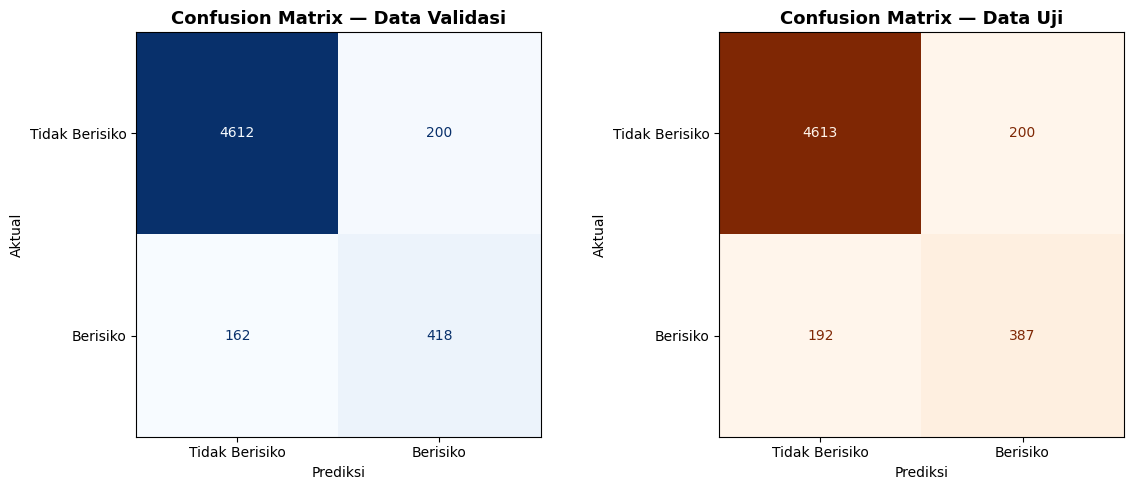

Confusion matrix disimpan ke output/confusion_matrix.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_display = ['Tidak Berisiko', 'Berisiko']

# Confusion Matrix Validasi
disp_v = ConfusionMatrixDisplay(confusion_matrix=cm_v,
                                 display_labels=labels_display)
disp_v.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Data Validasi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion Matrix Test
disp_t = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=labels_display)
disp_t.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix — Data Uji', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix disimpan ke output/confusion_matrix.png")

## 15. Visualisasi Perbandingan Metrik Evaluasi

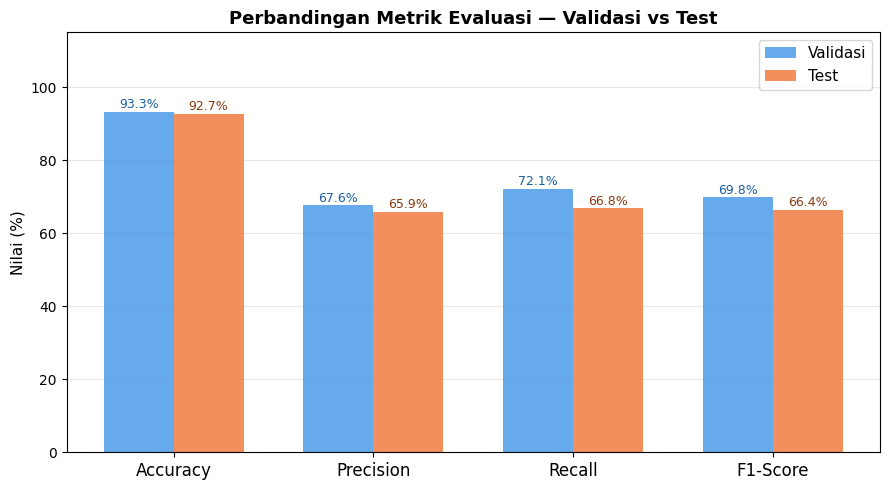

 Grafik metrik disimpan ke output/metrik_evaluasi.png


In [39]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
val_scores = [acc_v*100, prec_v*100, rec_v*100, f1_v*100]
test_scores = [acc*100,  prec*100,  rec*100,   f1*100]

x   = np.arange(len(metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, val_scores,  w, label='Validasi', color='#4C9BE8', alpha=0.85)
bars2 = ax.bar(x + w/2, test_scores, w, label='Test',     color='#F07C41', alpha=0.85)

ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Nilai (%)', fontsize=11)
ax.set_title('Perbandingan Metrik Evaluasi — Validasi vs Test', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#1a5f9e')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, color='#8a3a0f')

plt.tight_layout()
plt.savefig('output/metrik_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grafik metrik disimpan ke output/metrik_evaluasi.png")

## 16. Simpan Model ke Joblib

Model disimpan **tanpa fungsi/lambda** agar aman di-load di environment manapun.

In [40]:
print("=" * 60)
print("  LANGKAH 10 — SIMPAN MODEL KE JOBLIB")
print("=" * 60)

os.makedirs('model', exist_ok=True)
output_path = 'model/model_naive_bayes.joblib'

joblib.dump({
    'model'      : nb_model,
    'vectorizer' : tfidf,
    'stopwords'  : list(STOPWORDS),
    'kata_kasar' : list(KATA_KASAR),
    'pola_url'   : POLA_URL,
    'label_map'  : label_map,
    'metadata'   : {
        'total_data'       : len(df_all),
        'train_size'       : len(X_train),
        'val_size'         : len(X_val),
        'test_size'        : len(X_test),
        'accuracy_val'     : round(acc_v,  4),
        'precision_val'    : round(prec_v, 4),
        'recall_val'       : round(rec_v,  4),
        'f1_score_val'     : round(f1_v,   4),
        'accuracy_test'    : round(acc,    4),
        'precision_test'   : round(prec,   4),
        'recall_test'      : round(rec,    4),
        'f1_score_test'    : round(f1,     4),
        'confusion_matrix_val'  : cm_v.tolist(),
        'confusion_matrix_test' : cm.tolist(),
        'label_encoding'   : '1=Berisiko, 0=Tidak Berisiko',
        'tfidf_params'     : {
            'ngram_range'   : '(1,2)',
            'max_features'  : 10000,
            'sublinear_tf'  : True,
            'min_df'        : 2,
            'analyzer'      : 'word',
        },
        'nb_alpha'         : 1.0,
        'split_ratio'      : '70:15:15',
        'dataset_sources'  : ['dataset_fixed.csv (dummy)', 'spam.csv (Kaggle)'],
        'preprocessing_steps' : [
            '1. Case Folding (lowercase)',
            '2. Pattern Replacement (URL_CURIGA/NOMOR_HP_ASING/KODE_OTP/NOMINAL_UANG)',
            '3. Tokenisasi',
            '4. Stopword Removal (Sastrawi + custom English, kata kasar dijaga)',
            '5. Stemming Nazief-Adriani (token khusus & kata kasar skip)',
            '6. Ekstraksi Fitur TF-IDF (1,2)-gram max 10000 fitur',
        ],
    }
}, output_path)

size_kb = os.path.getsize(output_path) / 1024
print(f"    Model disimpan ke: {output_path}")
print(f"  Ukuran file : {size_kb:.1f} KB")
print(f"  Keys        : {list(joblib.load(output_path).keys())}")

  LANGKAH 10 — SIMPAN MODEL KE JOBLIB
    Model disimpan ke: model/model_naive_bayes.joblib
  Ukuran file : 2126.9 KB
  Keys        : ['model', 'vectorizer', 'stopwords', 'kata_kasar', 'pola_url', 'label_map', 'metadata']


## 17. Uji Prediksi — Fungsi Klasifikasi Berlapis

Implementasi fungsi `prediksi()` dengan 6 layer rule-based sesuai Gambar 3.3 rancangan skripsi.

In [41]:

# ── Fungsi prediksi berlapis — versi diperbaiki ─────────────────────────────
# Perbaikan utama:
# 1) Normalisasi karakter obfuscation: k0nt0l → kontol, b@ngs@t → bangsat
# 2) Whitelist konteks aman: anjing laut, babi hutan, contoh kata kasar, dll.
# 3) Rule khusus sebelum Naive Bayes: self-harm, narkoba, judi, cyber abuse,
#    social engineering, URL mencurigakan, ancaman, konten dewasa, kata kasar.
# 4) Naive Bayes hanya dipakai jika teks belum jelas terdeteksi oleh rule.

KATA_AMBIGUOUS = {'porno', 'bugil', 'telanjang', 'mesum'}

SAFE_CONTEXT = {
    'anjing laut',
    'babi hutan',
    'salah satu primata',
    'cerita rakyat',
    'contoh kata kasar',
    'kata kasar',
    'kata goblok sering dianggap tidak sopan',
    'dianggap tidak sopan',
    'sering dianggap tidak sopan',
    'transfer berhasil',
    'rekening bca',
    'nanti ketemu di kantin',
    'ketemu di kantin',
    'sudah saya kirim email',
    'cek inbox',
    'saldo bca',
    'pesanan kamu sedang dalam proses pengiriman',
    'selamat datang di aplikasi',
    'silakan login untuk melanjutkan',
    'rapat koordinasi dijadwalkan ulang',
    'dijadwalkan ulang ke kamis',
    'aplikasi error terus',
    'gabisa login dari tadi',
    'analisis kalimat',
    'meneliti ujaran',
    'ujaran kebencian',
    'film berjudul',
    'materi hari ini membahas phishing',
    'membahas phishing dan scam',
}

SELF_HARM_PATTERNS = {
    'bunuh diri', 'mengakhiri hidup', 'mati saja', 'mati aja',
    'capek hidup', 'tidak ada alasan untuk hidup', 'tak ada alasan untuk hidup',
    'tidak sanggup hidup', 'melukai diri', 'melukai diriku',
    'menghilang selamanya', 'cara untuk mati', 'lebih baik mati',
    'kalau aku tidak ada', 'ingin mengakhiri hidup', 'ingin bunuh diri'
}

DRUG_PATTERNS = {
    'sabu', 'ganja', 'narkoba', 'narkotika', 'putaw', 'kokain', 'ekstasi',
    'jual sabu', 'beli ganja', 'beli kokain', 'paket ekstasi',
    'transaksi ganja', 'distributor narkotika', 'obat terlarang',
    'obat terlarang paling kuat'
}

GAMBLING_PATTERNS = {
    'slot gacor', 'judi online', 'togel', 'casino', 'poker', 'jackpot',
    'taruhan', 'bandar togel', 'deposit sekarang menang besar',
    'bonus member baru', 'menang besar'
}

CYBER_PATTERNS = {
    'hack akun', 'keylogger', 'mencuri password', 'password wifi',
    'script phishing', 'bypass otp', 'crack software', 'jual database',
    'bobol akun', 'sql injection', 'exploit website', 'unduh malware',
    'mengontrol hp korban'
}

SOCIAL_ENGINEERING_PATTERNS = {
    'kode otp', 'kirim otp', 'berikan otp', 'kode verifikasi',
    'kirim password', 'kirim sandi', 'minta pin', 'pin atm', 'pin m banking',
    'cvv', 'nomor kartu', 'isi email dan password', 'akun anda diblokir',
    'akun anda dibekukan', 'rekening tidak diblokir', 'buka blokir akun',
    'verifikasi identitas', 'klaim hadiah', 'menang rp', 'memenangkan undian',
    'saldo gratis', 'winner', 'lucky winner', 'free entry', 'text to',
    'profit 30', 'dijamin wa'
}

THREAT_PATTERNS = {
    'gue habisin', 'gue bunuh', 'gue cari', 'gue sikat', 'gue tembak',
    'gue bakar', 'nyawa lo gue ambil', 'jangan sampe ketemu', 'gue hajar',
    'rumah lo gue bakar', 'awas lo', 'berani berani'
}

ADULT_PATTERNS = {
    'bokep', 'video porno', 'porno gratis', 'foto bugil', 'konten telanjang',
    'nonton bokep', 'nonton yang mesum', 'gabung grup foto bugil'
}

HARASSMENT_PATTERNS = {
    'ga pantas hidup', 'tidak pantas hidup', 'harap lo celaka',
    'bodoh seperti kamu', 'hidup lo ga ada gunanya', 'sampah masyarakat', 'manusia gagal',
    'beban keluarga', 'ga ada yang suka sama lo', 'jangan muncul lagi'
}

# Kata kasar tambahan untuk prediksi. Tidak bergantung penuh pada training model.
KATA_KASAR_DETEKSI = set(KATA_KASAR) | {
    'kontol','memek','pepek','titit','toket','ngentot','entot','ngewe',
    'bokep','porno','telanjang','bugil','mesum','cabul',
    'anjing','bangsat','bajingan','brengsek','keparat','sialan',
    'babi','goblok','goblog','tolol','dungu','geblek','kampret',
    'asu','jancok','jancuk','cuk','taik','tai','setan','iblis',
    'pukimak','bacot','bego','monyet','bedebah','anjir','anjirr',
    'anjg','njing','njir','njirr','mampus','hajar'
}

# Bentuk compact untuk menangkap obfuscation: a.n.j.i.n.g, a n j i n g, k0nt0l, b@ngs@t.
KATA_KASAR_COMPACT = {
    re.sub(r'[^a-z0-9]', '', w) for w in KATA_KASAR_DETEKSI
}

# Alias compact untuk bentuk obfuscation yang huruf vokalnya sengaja dihapus.
# Contoh: g*b*l*k -> gblk, k*n*t*l -> kntl, b*b* -> bb.
KATA_KASAR_COMPACT_ALIASES = {
    'gblk': 'goblok',
    'gblg': 'goblog',
    'kntl': 'kontol',
    'kontl': 'kontol',
    'anjng': 'anjing',
    'bngst': 'bangsat',
    'bbi': 'babi',
    'bb': 'babi',
    'pukmk': 'pukimak',
    'bct': 'bacot',
    'njng': 'njing',
}
KATA_KASAR_COMPACT.update(KATA_KASAR_COMPACT_ALIASES.keys())

LEET_MAP = str.maketrans({
    '0': 'o', '1': 'i', '3': 'e', '4': 'a', '5': 's', '7': 't',
    '@': 'a', '$': 's', '!': 'i'
})

POLA_URL_RULE = re.compile(
    r'(https?://|hxxps?://|ftp://|www\.|'
    r'bit\s*\.?\s*ly|bitly\.com|bit\.ly|s\.id|rb\.gy|t\.ly|cutt\.ly|'
    r'tinyurl\.com|shorturl\.at|goo\.gl|wa\.me|t\.me|'
    r'\b\d{1,3}(?:\.\d{1,3}){3}\b|'
    r'\[dot\]|\sdot\s|'
    r'[a-z0-9-]+\.(xyz|site|top|click|info|online|store|link|live)\b)',
    re.IGNORECASE
)

def _is_kemungkinan_nama(teks: str) -> bool:
    """Layer 2: Cek apakah pesan hanya berisi nama orang."""
    words = teks.strip().split()
    if not words or len(words) > 5:
        return False
    return (all(w[0].isupper() for w in words if w) and
            bool(re.match(r'^[A-Za-z\s]+$', teks.strip())))

def _normalize_for_rules(text: str) -> tuple[str, str, set]:
    """Return: teks normal ber-spasi, teks compact, token set."""
    raw = str(text).lower().strip()
    raw = raw.translate(LEET_MAP)

    # Normalisasi domain obfuscated: bank[dot]com / bank dot com
    raw = raw.replace('[dot]', '.')
    raw = re.sub(r'\bdot\b', '.', raw)

    spaced = re.sub(r'[^a-z0-9_./:\s-]', ' ', raw)
    spaced = re.sub(r'([a-z])\1{2,}', r'\1', spaced)  # goblokkkkk → goblok, anjinggg → anjing
    spaced = re.sub(r'\s+', ' ', spaced).strip()

    # Untuk obfuscation penuh: a.n.j.i.n.g / a n j i n g → anjing
    compact = re.sub(r'[^a-z0-9]', '', spaced)
    compact = re.sub(r'([a-z])\1{2,}', r'\1', compact)

    token_text = re.sub(r'[^a-z0-9_\s]', ' ', spaced)
    tokens = set(token_text.split())
    return spaced, compact, tokens

def _contains_any_phrase(text, phrases):
    for phrase in sorted(phrases, key=len, reverse=True):
        if phrase in text:
            return phrase
    return None

def _contains_bad_word(spaced, compact, tokens):
    # Deteksi token normal
    found = tokens & KATA_KASAR_DETEKSI
    if found:
        return ', '.join(sorted(found))

    # Deteksi kata kasar dengan huruf berulang: kontoll, babiiiii, koooontol
    for token in tokens:
        token_norm = re.sub(r'([a-z])\1{1,}', r'\1', token)
        if token_norm in KATA_KASAR_DETEKSI or token_norm in KATA_KASAR_COMPACT:
            return token

    # Deteksi compact alias untuk obfuscation tanpa vokal: g*b*l*k → gblk → goblok
    for alias, canonical in KATA_KASAR_COMPACT_ALIASES.items():
        if alias in compact:
            return canonical

    # Deteksi compact untuk obfuscation: a.n.j.i.n.g, k0nt0l, b@ngs@t
    for bad in sorted(KATA_KASAR_COMPACT, key=len, reverse=True):
        if len(bad) >= 4 and bad in compact:
            return bad
    return None

def _preprocess_for_nb(pesan: str) -> tuple[str, list[str]]:
    """Preprocessing yang disamakan dengan training sebelum TF-IDF."""
    t = str(pesan).lower().strip()
    t = re.sub(POLA_URL, 'URL_CURIGA', t)
    t = re.sub(r'\b0\d[\d\-]{8,12}\b', 'NOMOR_HP_ASING', t)
    t = re.sub(r'\b\d{5,8}\b', 'KODE_OTP', t)
    t = re.sub(r'rp[\s]?\d+[\.,]?\d*\s*(juta|ribu|rb)?', 'NOMINAL_UANG', t)
    t = re.sub(r'\b\d+\b', '', t)
    t = re.sub(r'[^a-zA-Z_\s]', ' ', t)
    tks = [x for x in t.split() if len(x) > 0]
    tks = [x for x in tks if x.isupper() or x in KATA_KASAR
           or (x not in STOPWORDS and len(x) > 1)]
    tks = [x if (x.isupper() or x in KATA_KASAR) else stemmer.stem(x) for x in tks]
    bersih = ' '.join(tks) if tks else 'PESAN_KOSONG'
    return bersih, tks

def prediksi(pesan: str) -> dict:
    """
    Klasifikasi pesan hybrid rule-based + Naive Bayes.

    Urutan layer:
    Layer 1  : teks terlalu pendek → Tidak Berisiko
    Layer 2  : kemungkinan nama orang → Tidak Berisiko
    Layer 3  : whitelist konteks aman → Tidak Berisiko
    Layer 4  : self-harm → Berisiko
    Layer 5  : narkoba → Berisiko
    Layer 6  : judi → Berisiko
    Layer 7  : cyber abuse/malware → Berisiko
    Layer 8  : social engineering/penipuan → Berisiko
    Layer 9  : URL mencurigakan → Berisiko
    Layer 10 : ancaman kekerasan → Berisiko
    Layer 11 : konten dewasa → Berisiko
    Layer 12 : harassment → Berisiko
    Layer 13 : kata kasar/obfuscation → Berisiko
    Layer 14 : token terlalu sedikit → Tidak Berisiko
    Model NB : dipakai untuk teks umum yang belum tertangkap rule
    """
    pesan = str(pesan).strip()

    if len(pesan) < 4:
        return {'label': 'Tidak Berisiko', 'keyakinan': 99.0,
                'layer': 'Layer 1 — Teks terlalu pendek'}

    if _is_kemungkinan_nama(pesan):
        return {'label': 'Tidak Berisiko', 'keyakinan': 95.0,
                'layer': 'Layer 2 — Kemungkinan nama orang'}

    spaced, compact, tokens = _normalize_for_rules(pesan)

    safe_hit = _contains_any_phrase(spaced, SAFE_CONTEXT)
    if safe_hit:
        return {'label': 'Tidak Berisiko', 'keyakinan': 96.0,
                'layer': f'Layer 3 — Konteks aman: {safe_hit}'}

    hit = _contains_any_phrase(spaced, SELF_HARM_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 97.0,
                'layer': f'Layer 4 — Self-harm: {hit}'}

    hit = _contains_any_phrase(spaced, DRUG_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 96.0,
                'layer': f'Layer 5 — Narkoba: {hit}'}

    hit = _contains_any_phrase(spaced, GAMBLING_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 96.0,
                'layer': f'Layer 6 — Judi: {hit}'}

    hit = _contains_any_phrase(spaced, CYBER_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 94.0,
                'layer': f'Layer 7 — Cyber abuse: {hit}'}

    hit = _contains_any_phrase(spaced, SOCIAL_ENGINEERING_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 95.0,
                'layer': f'Layer 8 — Social engineering: {hit}'}

    # Deteksi URL tersamarkan dibuat berbasis pola, bukan substring compact.
    # Ini mencegah false positive seperti kata "koordinasi dijadwalkan" yang mengandung "s.id" secara tidak sengaja.
    URL_OBFUSCATED_PATTERNS = [
        r'\bb\s*i\s*t\s*\.?\s*l\s*y\b',       # b i t . l y
        r'\bbit\s*\.?\s*ly\b',
        r'\bs\s*\.?\s*id\b',
        r'\brb\s*\.?\s*gy\b',
        r'\bgoo\s*\.?\s*gl\b',
        r'\bt\s*\.?\s*me\b',
        r'\bwa\s*\.?\s*me\b',
        r'\btinyurl\s*\.?\s*com\b',
        r'\bshorturl\s*\.?\s*at\b',
        r'\bcutt\s*\.?\s*ly\b',
    ]
    found_obfuscated_url = any(re.search(pat, spaced, re.IGNORECASE) for pat in URL_OBFUSCATED_PATTERNS)
    if POLA_URL_RULE.search(spaced) or found_obfuscated_url:
        return {'label': 'Berisiko', 'keyakinan': 95.0,
                'layer': 'Layer 9 — URL mencurigakan'}

    hit = _contains_any_phrase(spaced.replace('-', ' '), THREAT_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 96.0,
                'layer': f'Layer 10 — Ancaman kekerasan: {hit}'}

    hit = _contains_any_phrase(spaced, ADULT_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 96.0,
                'layer': f'Layer 11 — Konten dewasa: {hit}'}

    hit = _contains_any_phrase(spaced, HARASSMENT_PATTERNS)
    if hit:
        return {'label': 'Berisiko', 'keyakinan': 94.0,
                'layer': f'Layer 12 — Harassment: {hit}'}

    found_kasar = _contains_bad_word(spaced, compact, tokens)
    if found_kasar:
        return {'label': 'Berisiko', 'keyakinan': 99.0,
                'layer': f'Layer 13 — Kata kasar/obfuscation: {found_kasar}'}

    bersih, tks = _preprocess_for_nb(pesan)

    if len(tks) < 2:
        return {'label': 'Tidak Berisiko', 'keyakinan': 90.0,
                'layer': 'Layer 14 — Token tidak cukup'}

    vec = tfidf.transform([bersih])
    prob = nb_model.predict_proba(vec)[0]

    # Threshold tetap 65%, tetapi label disesuaikan agar tidak membalik confidence.
    label = 'Berisiko' if prob[1] >= 0.65 else 'Tidak Berisiko'
    confidence = prob[1] if label == 'Berisiko' else prob[0]

    return {'label': label, 'keyakinan': round(confidence * 100, 2),
            'layer': f'Model NB — P(Berisiko)={prob[1]*100:.1f}%'}

# ── Test Cases ────────────────────────────────────────────────────
test_cases = [
    # ── TIDAK BERISIKO: EDGE CASE ─────────────────────────────────────────────
    ("Tidak Berisiko", "anjing laut itu hidup di daerah dingin"),
    ("Tidak Berisiko", "babi hutan sering ditemukan di Sumatera"),
    ("Tidak Berisiko", "monyet adalah salah satu primata"),
    ("Tidak Berisiko", "setan dalam cerita rakyat memiliki banyak versi"),
    ("Tidak Berisiko", "film berjudul Anjing-Anjing Pemburu cukup terkenal"),
    ("Tidak Berisiko", "kata goblok sering dianggap tidak sopan"),
    ("Tidak Berisiko", "saya sedang meneliti ujaran kebencian di media sosial"),
    ("Tidak Berisiko", "contoh kata kasar adalah anjing dan babi"),
    ("Tidak Berisiko", "tolong analisis kalimat 'dasar anjing kamu'"),
    ("Tidak Berisiko", "materi hari ini membahas phishing dan scam online"),

    # ── BERISIKO: CYBER / MALWARE ─────────────────────────────────────────────
    ("Berisiko", "cara hack akun instagram orang lain"),
    ("Berisiko", "download keylogger gratis"),
    ("Berisiko", "cara mencuri password wifi tetangga"),
    ("Berisiko", "script phishing facebook terbaru"),
    ("Berisiko", "cara bypass otp bank"),
    ("Berisiko", "crack software premium tanpa bayar"),
    ("Berisiko", "jual database pelanggan lengkap"),
    ("Berisiko", "cara bobol akun gmail"),
    ("Berisiko", "exploit website target menggunakan sql injection"),
    ("Berisiko", "unduh malware untuk mengontrol hp korban"),

    # ── BERISIKO: DISGUISED URL ───────────────────────────────────────────────
    ("Berisiko", "klik b i t . l y / hadiah sekarang"),
    ("Berisiko", "akses bank-login dot xyz sekarang"),
    ("Berisiko", "kunjungi hxxp://bonus-saldo.xyz"),
    ("Berisiko", "cek hadiah di bi t .ly /claim"),
    ("Berisiko", "login di bank[dot]security-verif[dot]com"),
    ("Berisiko", "verifikasi akun melalui tinyurl.com/bonus123"),
    ("Berisiko", "akses goo.gl/reward"),
    ("Berisiko", "buka link berikut t.me/bonusgratis"),
    ("Berisiko", "join grup hadiah di wa.me/628123456789"),
    ("Berisiko", "cek promo di bitly.com/claimreward"),

    # ── BERISIKO: SOCIAL ENGINEERING LANJUTAN ────────────────────────────────
    ("Berisiko", "saya dari bank, sebutkan nomor kartu anda"),
    ("Berisiko", "berikan cvv kartu kredit anda"),
    ("Berisiko", "tolong kirim otp yang baru masuk"),
    ("Berisiko", "konfirmasi pin m banking anda"),
    ("Berisiko", "masukkan password email untuk validasi"),
    ("Berisiko", "akun anda dibekukan segera verifikasi identitas"),
    ("Berisiko", "klik tautan berikut agar rekening tidak diblokir"),
    ("Berisiko", "data anda tidak valid silakan kirim nik dan pin"),
    ("Berisiko", "klaim hadiah sekarang sebelum hangus"),
    ("Berisiko", "anda memenangkan undian nasional sebesar 500 juta"),

    # ── BERISIKO: UJARAN KEBENCIAN / HARASSMENT ──────────────────────────────
    ("Berisiko", "orang kayak lo ga pantas hidup"),
    ("Berisiko", "semua orang bodoh seperti kamu"),
    ("Berisiko", "gue harap lo celaka"),
    ("Berisiko", "hidup lo ga ada gunanya"),
    ("Berisiko", "pergi sana sampah masyarakat"),
    ("Berisiko", "dasar manusia gagal"),
    ("Berisiko", "mending lo mati aja"),
    ("Berisiko", "ga ada yang suka sama lo"),
    ("Berisiko", "lo memang beban keluarga"),
    ("Berisiko", "jangan muncul lagi di depan gue"),

    # ── BERISIKO: SELF-HARM / BUNUH DIRI ─────────────────────────────────────
    ("Berisiko", "aku ingin mengakhiri hidupku"),
    ("Berisiko", "lebih baik mati saja"),
    ("Berisiko", "aku capek hidup"),
    ("Berisiko", "tidak ada alasan untuk hidup lagi"),
    ("Berisiko", "aku ingin bunuh diri"),
    ("Berisiko", "aku sudah menyiapkan cara untuk mati"),
    ("Berisiko", "semuanya akan lebih baik kalau aku tidak ada"),
    ("Berisiko", "aku ingin melukai diriku sendiri"),
    ("Berisiko", "aku tidak sanggup hidup lagi"),
    ("Berisiko", "aku ingin menghilang selamanya"),

    # ── BERISIKO: NARKOBA ────────────────────────────────────────────────────
    ("Berisiko", "jual sabu kualitas terbaik"),
    ("Berisiko", "cara membuat narkoba sendiri"),
    ("Berisiko", "tempat beli ganja online"),
    ("Berisiko", "paket ekstasi murah"),
    ("Berisiko", "jual putaw aman"),
    ("Berisiko", "distributor narkotika terpercaya"),
    ("Berisiko", "cara konsumsi sabu yang benar"),
    ("Berisiko", "beli kokain tanpa resep"),
    ("Berisiko", "obat terlarang paling kuat"),
    ("Berisiko", "transaksi ganja via telegram"),

    # ── BERISIKO: JUDI ───────────────────────────────────────────────────────
    ("Berisiko", "slot gacor hari ini"),
    ("Berisiko", "deposit sekarang menang besar"),
    ("Berisiko", "prediksi togel malam ini"),
    ("Berisiko", "link judi online terpercaya"),
    ("Berisiko", "main casino online resmi"),
    ("Berisiko", "bonus member baru 100 persen"),
    ("Berisiko", "pasang taruhan sekarang"),
    ("Berisiko", "bandar togel terbesar"),
    ("Berisiko", "situs poker online terbaik"),
    ("Berisiko", "jackpot slot gampang menang"),

    # ── BERISIKO: OBFUSCATED PROFANITY ───────────────────────────────────────
    ("Berisiko", "@nj!ng lo"),
    ("Berisiko", "a.n.j.i.n.g"),
    ("Berisiko", "k0nt0l"),
    ("Berisiko", "g*b*l*k"),
    ("Berisiko", "b@ngs@t"),
    ("Berisiko", "goblokkkkkkkkk"),
    ("Berisiko", "koooontol"),
    ("Berisiko", "babiiiii"),
    ("Berisiko", "anjg lu"),
    ("Berisiko", "njing banget"),

    # ── TIDAK BERISIKO ──────────────────────────────────────────────────────
    ("Tidak Berisiko", "p"),
    ("Tidak Berisiko", "ok"),
    ("Tidak Berisiko", "Budi Santoso"),
    ("Tidak Berisiko", "Siti Rahayu"),
    ("Tidak Berisiko", "Muhammad Fauzi"),
    ("Tidak Berisiko", "ok siap nanti gue hubungi balik"),
    ("Tidak Berisiko", "udah makan belum? tadi beli nasi padang"),
    ("Tidak Berisiko", "besok jadi berangkat kan? tunggu di stasiun jam 7"),
    ("Tidak Berisiko", "Transfer berhasil Rp250.000 ke rekening BCA atas nama Budi"),
    ("Tidak Berisiko", "Jangan lupa kumpul tugas sebelum hari Jumat"),
    ("Tidak Berisiko", "Acara seminar nasional dimulai pukul 09.00 WIB"),
    ("Tidak Berisiko", "halo kak, gimana kabarnya?"),
    ("Tidak Berisiko", "nanti ketemu di kantin ya jam 12"),
    ("Tidak Berisiko", "tugas matematika udah dikumpul belum?"),
    ("Tidak Berisiko", "selamat ulang tahun semoga panjang umur dan sehat selalu"),
    ("Tidak Berisiko", "hari ini macet banget di tol"),
    ("Tidak Berisiko", "bisa tolong kirimin file presentasinya"),
    ("Tidak Berisiko", "meeting jam 3 sore di ruang rapat lantai 2"),
    ("Tidak Berisiko", "cuaca hari ini panas banget ya"),
    ("Tidak Berisiko", "terima kasih sudah membantu kemarin"),
    ("Tidak Berisiko", "bentar lagi sampe kok sabar ya"),
    ("Tidak Berisiko", "izin tidak masuk hari ini karena sakit"),
    ("Tidak Berisiko", "sudah saya kirim email nya cek inbox"),
    ("Tidak Berisiko", "besok libur nasional jadi kantor tutup"),
    ("Tidak Berisiko", "laporan keuangan bulan ini sudah selesai"),
    ("Tidak Berisiko", "Saldo BCA kamu Rp1.250.000 per 07 Juni 2025"),
    ("Tidak Berisiko", "Pembayaran tagihan listrik Rp185.000 berhasil"),
    ("Tidak Berisiko", "Pesanan kamu sedang dalam proses pengiriman"),
    ("Tidak Berisiko", "Selamat datang di aplikasi. Silakan login untuk melanjutkan"),
    ("Tidak Berisiko", "Rapat koordinasi dijadwalkan ulang ke Kamis pukul 10.00"),
    ("Tidak Berisiko", "nilai ujian tengah semester sudah bisa dilihat di portal"),
    ("Tidak Berisiko", "tolong ingatkan aku beli obat nanti pulang kerja"),
    ("Tidak Berisiko", "film tadi bagus banget endingnya bikin nangis"),
    ("Tidak Berisiko", "wifi di sini lemot banget gabisa buka apa apa"),
    ("Tidak Berisiko", "absen dulu ya pak sebelum mulai"),
    ("Tidak Berisiko", "deadline pengumpulan laporan tanggal 15"),
    ("Tidak Berisiko", "nanti mampir ke rumah bawa snack ya"),
    ("Tidak Berisiko", "aplikasi error terus gabisa login dari tadi"),
    ("Tidak Berisiko", "tolong review PR saya di github"),
    ("Tidak Berisiko", "jadwal piket minggu ini siapa aja"),

    # ── BERISIKO: KATA KASAR LANGSUNG ───────────────────────────────────────
    ("Berisiko", "kontol lo!"),
    ("Berisiko", "kontol lahh kau babi"),
    ("Berisiko", "BANGSAT!!"),
    ("Berisiko", "dasar anjing kamu"),
    ("Berisiko", "babi lu ngomong apa"),
    ("Berisiko", "tai banget sih orang ini"),
    ("Berisiko", "goblog kamu tuh"),
    ("Berisiko", "kampret emang dasar"),
    ("Berisiko", "mampus lo sana"),
    ("Berisiko", "keparat kamu ini"),
    ("Berisiko", "sialan dasar munafik"),
    ("Berisiko", "pukimak kau"),
    ("Berisiko", "bangsat pergi sana"),
    ("Berisiko", "bacot mulu dari tadi"),
    ("Berisiko", "bego banget sih"),
    ("Berisiko", "monyet kamu tuh"),
    ("Berisiko", "bedebah emang orang itu"),
    ("Berisiko", "goblok banget lo"),
    ("Berisiko", "anjing beneran lo"),
    ("Berisiko", "setan kamu pergi"),

    # ── BERISIKO: PENGELAKAN KATA KASAR (EVASION) ───────────────────────────
    ("Berisiko", "anjinggg banget sih lo"),
    ("Berisiko", "4nj1ng lu"),
    ("Berisiko", "a n j i n g kamu"),
    ("Berisiko", "b4ngsat banget"),
    ("Berisiko", "g0bl0k kamu"),
    ("Berisiko", "kontoll lu"),
    ("Berisiko", "b*bi emang"),
    ("Berisiko", "k*ntol lo"),
    ("Berisiko", "anjirrr parah banget"),
    ("Berisiko", "njirr nyebelin banget"),

    # ── BERISIKO: ANCAMAN KEKERASAN ──────────────────────────────────────────
    ("Berisiko", "awas lo gue habisin nanti"),
    ("Berisiko", "gue bunuh kamu kalau berani"),
    ("Berisiko", "tunggu aja nanti gue cari"),
    ("Berisiko", "berani-berani lo gue sikat"),
    ("Berisiko", "mati aja lo sekalian"),
    ("Berisiko", "gue tembak kamu kalau ketemu"),
    ("Berisiko", "rumah lo gue bakar"),
    ("Berisiko", "nyawa lo gue ambil"),
    ("Berisiko", "jangan sampe ketemu di jalan"),
    ("Berisiko", "gue laporin dan gue hajar kamu"),

    # ── BERISIKO: KONTEN DEWASA / AMBIGU ────────────────────────────────────
    ("Berisiko", "yuk nonton bokep bareng"),
    ("Berisiko", "ayo lihat video porno sama aku"),
    ("Berisiko", "kirim foto bugil ke sini"),
    ("Berisiko", "mau nonton yang mesum yuk"),
    ("Berisiko", "share konten telanjang dong"),
    ("Berisiko", "download video porno gratis di sini"),
    ("Berisiko", "link bokep terbaru klik sini"),
    ("Berisiko", "gabung grup foto bugil"),

    # ── BERISIKO: PHISHING / URL BERBAHAYA ──────────────────────────────────
    ("Berisiko", "Akun BRI terdeteksi mencurigakan. Verifikasi di bit.ly/verif-bri"),
    ("Berisiko", "Download APK WhatsApp terbaru di shorturl.at/wa-update"),
    ("Berisiko", "klik link ini bit.ly/hadiahgratis untuk klaim"),
    ("Berisiko", "login ke https://bank-login.xyz/akun sekarang"),
    ("Berisiko", "verifikasi akun di hxxps://bank-palsu.xyz/login"),
    ("Berisiko", "buka hxxps://bank-palsu.xyz/login untuk konfirmasi"),
    ("Berisiko", "masuk ke http://192.168.1.1/login sekarang"),
    ("Berisiko", "akses s.id/bonussaldo untuk klaim reward"),
    ("Berisiko", "unduh aplikasi di cutt.ly/apk-update"),
    ("Berisiko", "cek hadiahmu di rb.gy/reward123"),

    # ── BERISIKO: PENIPUAN / SOCIAL ENGINEERING ──────────────────────────────
    ("Berisiko", "Selamat menang Rp50 juta. Klik link ini untuk klaim"),
    ("Berisiko", "Berikan kode OTP 819234 kepada saya untuk verifikasi"),
    ("Berisiko", "Bisnis online profit 30% dijamin WA 081234567890"),
    ("Berisiko", "Free entry win FA Cup final tkts! Text to 87121 apply T&C"),
    ("Berisiko", "WINNER!! You have been selected as a lucky winner of $1000"),
    ("Berisiko", "tolong kirim password akun kamu ke nomor ini untuk verifikasi"),
    ("Berisiko", "masukkan pin atm kamu di form berikut untuk konfirmasi"),
    ("Berisiko", "berikan kode verifikasi yang masuk ke hp kamu sekarang"),
    ("Berisiko", "selamat anda terpilih mendapat hadiah 100 juta hubungi kami"),
    ("Berisiko", "akun anda akan diblokir segera verifikasi dengan klik link ini"),
    ("Berisiko", "dapatkan saldo gratis Rp500.000 daftar sekarang"),
    ("Berisiko", "transfer Rp100.000 sekarang untuk buka blokir akun kamu"),
    ("Berisiko", "kirim sandi akun kamu ke admin untuk proses pemulihan"),
    ("Berisiko", "minta pin akun kamu sekarang untuk keamanan"),
    ("Berisiko", "isi email dan password kamu di form ini untuk verifikasi"),
]

print(f"  {'Ekspektasi':<16}  {'Hasil':<16}  {'Yakin':>7}  Sts  Layer / Pesan")
print("  " + "-"*100)
benar = 0
salah = []
for eks, pesan in test_cases:
    hasil  = prediksi(pesan)
    status = "✓ OK" if hasil['label'] == eks else "✗ SALAH"
    if hasil['label'] == eks:
        benar += 1
    else:
        salah.append((eks, pesan, hasil))
    print(f"  {eks:<16}  {hasil['label']:<16}  {hasil['keyakinan']:>5.1f}%  {status}  "
          f"[{hasil['layer']}] {pesan[:40]}")

print(f"\n  Hasil: {benar}/{len(test_cases)} benar ({benar/len(test_cases)*100:.0f}%)")

if salah:
    print("\n  ── Daftar Salah ──")
    for no, (eks, pesan, hasil) in enumerate(salah, 1):
        print(f"  {no}. Ekspektasi={eks} | Hasil={hasil['label']} | {hasil['layer']} | {pesan}")


  Ekspektasi        Hasil               Yakin  Sts  Layer / Pesan
  ----------------------------------------------------------------------------------------------------
  Tidak Berisiko    Tidak Berisiko     96.0%  ✓ OK  [Layer 3 — Konteks aman: anjing laut] anjing laut itu hidup di daerah dingin
  Tidak Berisiko    Tidak Berisiko     96.0%  ✓ OK  [Layer 3 — Konteks aman: babi hutan] babi hutan sering ditemukan di Sumatera
  Tidak Berisiko    Tidak Berisiko     96.0%  ✓ OK  [Layer 3 — Konteks aman: salah satu primata] monyet adalah salah satu primata
  Tidak Berisiko    Tidak Berisiko     96.0%  ✓ OK  [Layer 3 — Konteks aman: cerita rakyat] setan dalam cerita rakyat memiliki banya
  Tidak Berisiko    Tidak Berisiko     96.0%  ✓ OK  [Layer 3 — Konteks aman: film berjudul] film berjudul Anjing-Anjing Pemburu cuku
  Tidak Berisiko    Tidak Berisiko     96.0%  ✓ OK  [Layer 3 — Konteks aman: kata goblok sering dianggap tidak sopan] kata goblok sering dianggap tidak sopan
  Tidak Berisiko   

## 18. Ringkasan Hasil Pelatihan

In [21]:
print("=" * 60)
print("  RINGKASAN HASIL PELATIHAN MODEL")
print("=" * 60)
print(f"\n  Dataset:")
print(f"    Sumber 1  : SMS Spam Collection (Kaggle)  — {len(df_kaggle)} data")
print(f"    Sumber 2  : Dataset Dummy (Peneliti)       — {len(df_dummy)} data")
print(f"    Total     : {len(df_all)} data")
print(f"    Berisiko  : {sum(y==1)} | Tidak Berisiko: {sum(y==0)}")
print(f"\n  Split Ratio:")
print(f"    Train     : {len(X_train)} data (70%)")
print(f"    Validasi  : {len(X_val)} data (15%)")
print(f"    Test      : {len(X_test)} data (15%)")
print(f"\n  Konfigurasi Model:")
print(f"    Algoritma : Multinomial Naïve Bayes")
print(f"    Alpha     : 1.0 (Laplace smoothing)")
print(f"    TF-IDF    : ngram (1,2), max_features 10000, sublinear_tf True")
print(f"\n  Hasil Evaluasi:")
print(f"  {'Metrik':<14} {'Validasi':>12}  {'Test':>12}")
print("  " + "-"*42)
for nama, v, t in [
    ("Accuracy",  acc_v, acc),
    ("Precision", prec_v, prec),
    ("Recall",    rec_v, rec),
    ("F1-Score",  f1_v, f1),
]:
    print(f"  {nama:<14} {v*100:>10.2f}%   {t*100:>10.2f}%")
print(f"\n  File Model : model/model_naive_bayes.joblib")
print(f"  Ukuran     : {os.path.getsize('model/model_naive_bayes.joblib')/1024:.1f} KB")
print("\n" + "="*60)
print(" PELATIHAN SELESAI")
print("="*60)

  RINGKASAN HASIL PELATIHAN MODEL

  Dataset:


NameError: name 'df_kaggle' is not defined